In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Phase 1: Dataset Familiarization

In [163]:
df = pd.read_csv(r"data\Zara_sales.csv")
plt.rcParams['figure.figsize'] = (8, 5)
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [164]:
print(f"Rows: {df.shape[0]} & Columns: {df.shape[1]}")

Rows: 20252 & Columns: 17


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

In [166]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

Phase 2: Data Quality

In [167]:
df.describe()

,Product ID,Sales Volume,price
count,20252.000000,20252.000000,20252.000000
mean,208931.432303,1097.400454,41.949061
std,8961.076507,298.234609,23.380960
min,110075.000000,518.000000,12.000000
25%,204442.750000,849.000000,23.950000
50%,209505.500000,990.000000,35.950000
75%,214568.250000,1364.250000,53.950000
max,219631.000000,1940.000000,134.990000


In [168]:
df.describe(include = "object")

,Product Position,Promotion,Product Category,Seasonal,brand,url,name,description,currency,terms,section,season,material,origin
count,20252,20252,20252,20252,20252,20252,20251,20250,20252,20252,20252,20252,20252,20252
unique,3,2,1,2,1,228,17215,221,1,5,2,4,11,12
top,Aisle,No,clothing,No,Zara,https://www.zara.com/us/en/knit-sweater-with-r...,PLAID OVERSHIRT,Varsity jacket with elastic collar and long sl...,USD,jackets,WOMAN,Autumn,Cotton,China
freq,7810,11812,20252,10136,20252,187,8,333,20252,11232,13254,7665,3851,4026


In [169]:
df[['Sales Volume', 'price']].describe()

,Sales Volume,price
count,20252.000000,20252.000000
mean,1097.400454,41.949061
std,298.234609,23.380960
min,518.000000,12.000000
25%,849.000000,23.950000
50%,990.000000,35.950000
75%,1364.250000,53.950000
max,1940.000000,134.990000


In [170]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()[:10]}")

Product ID: 20252 unique -> [185102 188771 180176 112917 192936 117590 189118 182157 141861 137121]
Product Position: 3 unique -> ['Aisle' 'End-cap' 'Front of Store']
Promotion: 2 unique -> ['Yes' 'No']
Product Category: 1 unique -> ['clothing']
Seasonal: 2 unique -> ['Yes' 'No']
Sales Volume: 1284 unique -> [1243 1429 1168 1348 1602 1282  688 1711  857  769]
brand: 1 unique -> ['Zara']
url: 228 unique -> ['https://www.zara.com/us/en/basic-puffer-jacket-p06985450.html'
 'https://www.zara.com/us/en/tuxedo-jacket-p08896675.html'
 'https://www.zara.com/us/en/slim-fit-suit-jacket-p01564520.html'
 'https://www.zara.com/us/en/stretch-suit-jacket-p01564300.html'
 'https://www.zara.com/us/en/double-faced-jacket-p08281477.html'
 'https://www.zara.com/us/en/contrasting-collar-jacket-p06987331.html'
 'https://www.zara.com/us/en/faux-leather-puffer-jacket-p08281420.html'
 'https://www.zara.com/us/en/suit-jacket-in-100-linen-p04307408.html'
 'https://www.zara.com/us/en/100-wool-suit-jacket-p0595521

In [171]:
df.duplicated().sum()

np.int64(0)

Phase 3: Univariate Analysis

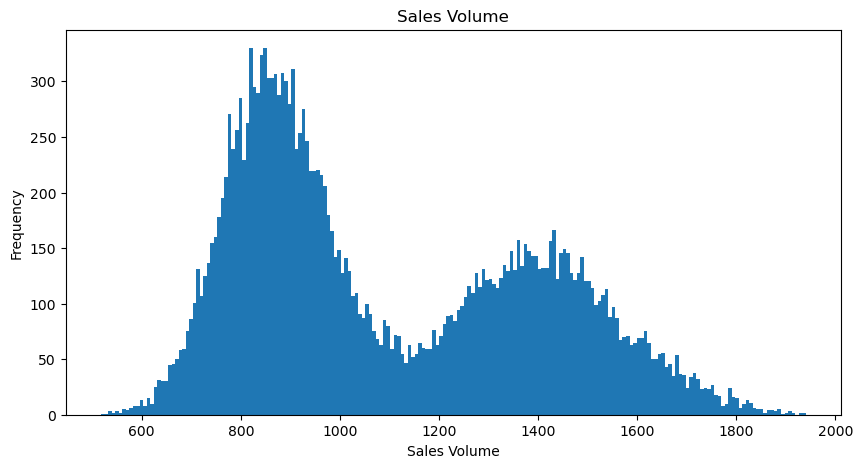

In [172]:
plt.figure(figsize = (10, 5))
plt.hist(df['Sales Volume'], bins = 200)
plt.title("Sales Volume")
plt.xlabel("Sales Volume")
plt.ylabel("Frequency")
plt.show()

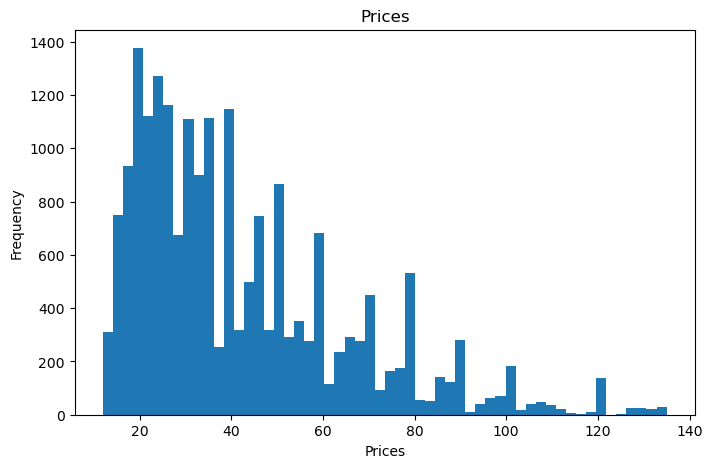

In [173]:
plt.hist(df['price'], bins = "auto")
plt.title("Prices")
plt.xlabel("Prices")
plt.ylabel("Frequency")
plt.show()

In [174]:
columns = ["Promotion", "section", "season", "terms", "Product Position", "material"]
for col in columns:
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    summary = pd.DataFrame({"count": counts, "%": pct})
    print("\n")
    print(summary)



           count     %
Promotion             
No         11812  58.3
Yes         8440  41.7


         count     %
section             
WOMAN    13254  65.4
MAN       6998  34.6


        count     %
season             
Autumn   7665  37.8
Winter   5144  25.4
Spring   4537  22.4
Summer   2906  14.3


          count     %
terms                
jackets   11232  55.5
sweaters   3257  16.1
t-shirts   2646  13.1
shoes      2458  12.1
jeans       659   3.3


                  count     %
Product Position             
Aisle              7810  38.6
End-cap            6791  33.5
Front of Store     5651  27.9


             count     %
material                
Cotton        3851  19.0
Wool          3805  18.8
Wool Blend    3373  16.7
Polyester     2775  13.7
Linen         2573  12.7
Denim         1027   5.1
Viscose        990   4.9
Acrylic        881   4.4
Linen Blend    807   4.0
Satin          132   0.7
Silk            38   0.2


Phase 4: Bivariate Analysis

In [175]:
corr = df[['Sales Volume', 'price']].corr()
corr

,Sales Volume,price
Sales Volume,1.00000,-0.33778
price,-0.33778,1.00000


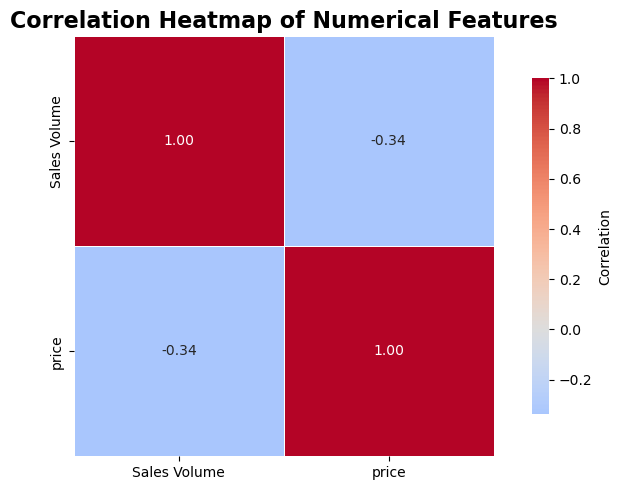

In [176]:
plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
            linewidths=0.5, linecolor="white", square=True, cbar_kws={"shrink": 0.8,
            "label": "Correlation"})

plt.title("Correlation Heatmap of Numerical Features", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

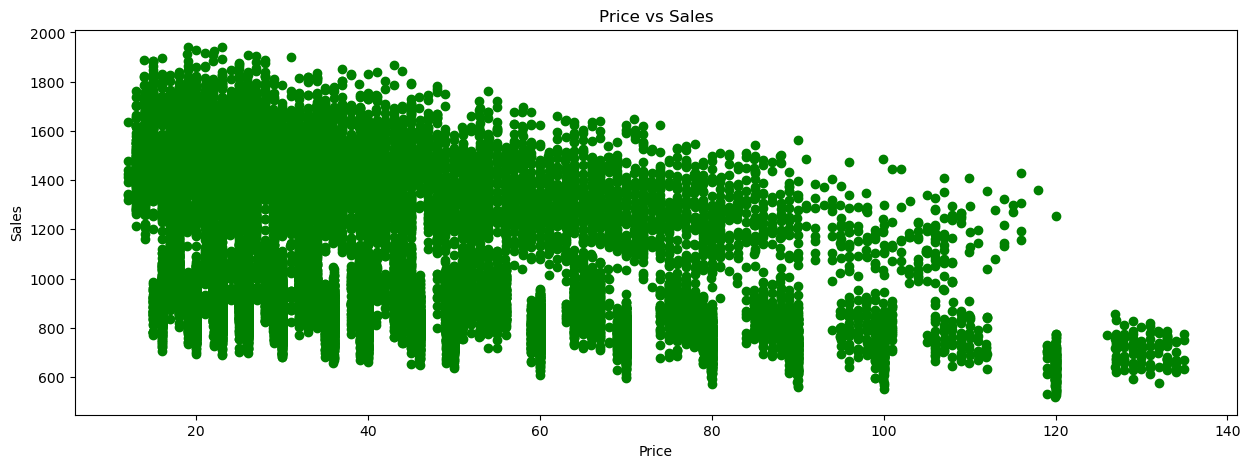

In [177]:
plt.figure(figsize = (15, 5))
plt.scatter(df["price"], df["Sales Volume"], c = 'green')
plt.title("Price vs Sales")
plt.xlabel("Price")
plt.ylabel("Sales")
plt.show()

In [178]:
def summarize_and_plot(df, col, target="Sales Volume", figsize=(8,5), rotate=False):
    summary = df.groupby(col)[[target, "price"]].agg(["mean", "median", "count"])
    print(summary)
    print("\n")
    plt.figure(figsize=figsize)
    sns.boxplot(data=df, x=col, y=target)
    plt.title(f"{target} by {col}")
    plt.xlabel(col)
    plt.ylabel(target)
    if rotate:
        plt.xticks(rotation=45)
    plt.show()

          Sales Volume                    price              
                  mean  median  count      mean median  count
Promotion                                                    
No          872.377074   868.0  11812  44.69179  38.99  11812
Yes        1412.326540  1406.0   8440  38.11054  31.99   8440




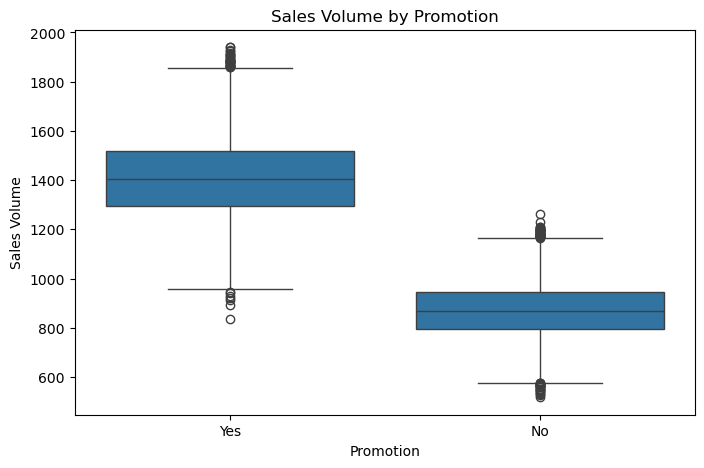

In [179]:
summarize_and_plot(df, "Promotion")

        Sales Volume                     price              
                mean  median  count       mean median  count
section                                                     
MAN      1023.636325   914.0   6998  42.125776  35.95   6998
WOMAN    1136.347291  1018.0  13254  41.855757  35.95  13254




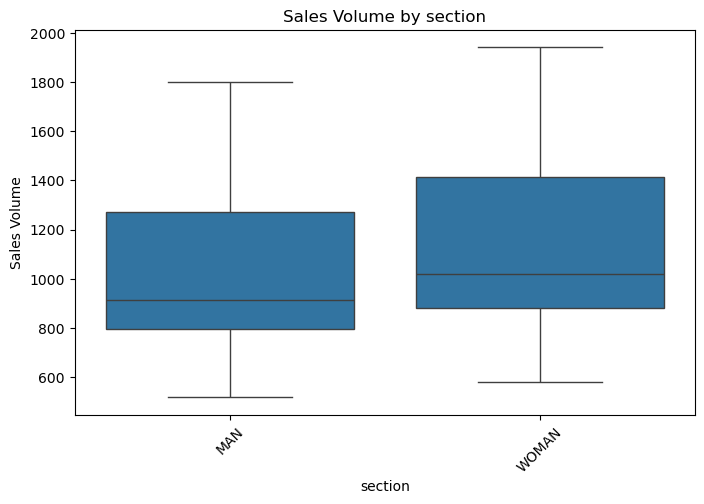

In [180]:
summarize_and_plot(df, "section", rotate=True)

       Sales Volume                    price             
               mean  median count       mean median count
season                                                   
Autumn  1042.819830   926.0  7665  40.526800  35.00  7665
Spring  1046.223496   928.0  4537  40.735105  35.95  4537
Summer  1184.589470  1059.0  2906  44.081700  37.99  2906
Winter  1174.612558  1046.0  5144  43.934267  36.99  5144




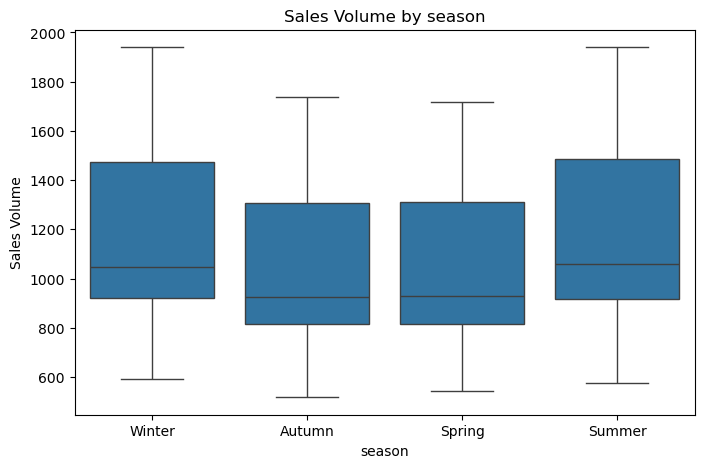

In [181]:
summarize_and_plot(df, "season")

         Sales Volume                    price              
                 mean median  count       mean median  count
terms                                                       
jackets   1099.371706  992.5  11232  41.560633  35.00  11232
jeans     1094.549317  980.0    659  42.917785  35.99    659
shoes     1089.089504  981.0   2458  42.400997  35.95   2458
sweaters  1104.925698  999.0   3257  41.773018  35.95   3257
t-shirts  1088.200302  982.0   2646  43.153500  35.99   2646




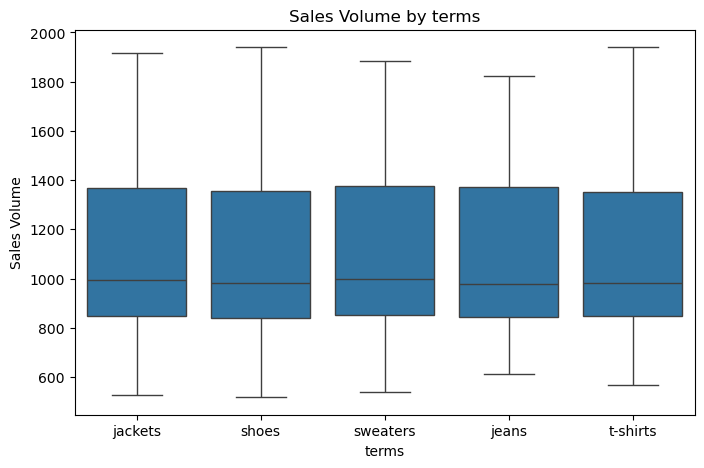

In [182]:
summarize_and_plot(df, "terms")

                 Sales Volume                   price             
                         mean median count       mean median count
Product Position                                                  
Aisle             1090.427401  979.0  7810  42.120601  35.95  7810
End-cap           1100.459726  995.0  6791  41.714086  35.95  6791
Front of Store    1103.361175  999.0  5651  41.994360  35.95  5651




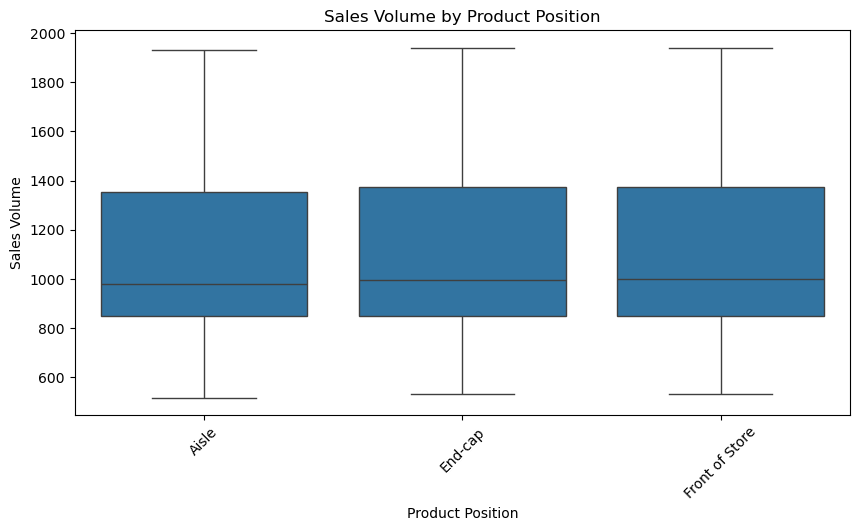

In [183]:
summarize_and_plot(df, "Product Position", figsize=(10,5), rotate=True)

In [184]:
def show_crosstab(df, col1, col2, normalize=False):
    ct = pd.crosstab(df[col1], df[col2], normalize='index' if normalize else False)
    return ct

In [185]:
show_crosstab(df, "Promotion", "section")

section,MAN,WOMAN
Promotion,,
No,4112,7700
Yes,2886,5554


In [186]:
show_crosstab(df, "Promotion", "season")

season,Autumn,Spring,Summer,Winter
Promotion,,,,
No,4470,2619,1667,3056
Yes,3195,1918,1239,2088


In [187]:
show_crosstab(df, "Promotion", "terms")

terms,jackets,jeans,shoes,sweaters,t-shirts
Promotion,,,,,
No,6535,392,1455,1861,1569
Yes,4697,267,1003,1396,1077


In [188]:
show_crosstab(df, "section", "season")

season,Autumn,Spring,Summer,Winter
section,,,,
MAN,2701,1597,990,1710
WOMAN,4964,2940,1916,3434


Phase 5: Multivariate Analysis

In [189]:
def two_way_summary(df, group_cols, target="Sales Volume"):
    summary = df.groupby(group_cols)[target].agg(["mean", "median", "count"])
    return summary

In [190]:
two_way_summary(df, ["Promotion", "section"])

mean  median  count
Promotion section                            
No        MAN       816.089981   813.0   4112
          WOMAN     902.435844   898.0   7700
Yes       MAN      1319.350312  1309.0   2886
          WOMAN    1460.639359  1454.0   5554

In [191]:
two_way_summary(df, ["Promotion", "season"])

mean  median  count
Promotion season                            
No        Autumn   829.537136   831.0   4470
          Spring   829.696067   829.0   2619
          Summer   935.459508   936.0   1667
          Winter   937.206152   940.0   3056
Yes       Autumn  1341.215336  1343.0   3195
          Spring  1341.888425  1344.0   1918
          Summer  1519.778854  1514.0   1239
          Winter  1522.080939  1525.0   2088

In [192]:
two_way_summary(df, ["Promotion", "terms"])

mean  median  count
Promotion terms                               
No        jackets    873.107116   869.0   6535
          jeans      872.829082   861.5    392
          shoes      869.246735   865.0   1455
          sweaters   872.975282   869.0   1861
          t-shirts   871.416826   867.0   1569
Yes       jackets   1414.176709  1408.0   4697
          jeans     1420.071161  1426.0    267
          shoes     1408.003988  1398.0   1003
          sweaters  1414.137536  1408.0   1396
          t-shirts  1404.015785  1397.0   1077

Phase 7: Investigating the URLs

In [193]:
df['url'].nunique()

228

In [194]:
df['url'].value_counts().head(10)

url
https://www.zara.com/us/en/knit-sweater-with-rips-p00021110.html                     187
https://www.zara.com/us/en/wool-blend-knit-sweater-p02893159.html                    185
https://www.zara.com/us/en/contrast-topstitching-crop-knit-sweater-p09598003.html    183
https://www.zara.com/us/en/hooded-technical-jacket-p01538301.html                    180
https://www.zara.com/us/en/basic-foil-knit-sweater-p00506101.html                    179
https://www.zara.com/us/en/soft-jewel-sweater-p02298153.html                         175
https://www.zara.com/us/en/v-neck-knit-sweater-p03519001.html                        167
https://www.zara.com/us/en/jewel-knit-sweater-p05755005.html                         166
https://www.zara.com/us/en/knit-v-neck-sweater-p06771003.html                        166
https://www.zara.com/us/en/fine-knit-crop-sweater-p09598029.html                     163
Name: count, dtype: int64

In [195]:
top_url = df['url'].value_counts().index[0]
rows = df[df['url'] == top_url]
print(rows['name'].nunique(), "unique names out of", len(rows), "rows")
print(rows['description'].nunique(), "unique descriptions out of", len(rows), "rows")

187 unique names out of 187 rows
125 unique descriptions out of 187 rows
